In [1]:
!pip install -q requests beautifulsoup4 pandas openpyxl matplotlib seaborn

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
import io
import base64
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')

In [4]:
def scrape_daraz(keyword, pages=2):
    """Scrape Daraz Nepal product data."""
    BASE_URL = "https://www.daraz.com.np"
    AJAX_URL = f"{BASE_URL}/catalog/?ajax=true&q="
    HEADERS = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
        'Accept': 'application/json, text/plain, */*',
        'X-Requested-With': 'XMLHttpRequest'
    }
    products = []
    session = requests.Session()
    session.headers.update(HEADERS)
    session.get(BASE_URL, timeout=10)  # get cookies

    for page in range(1, pages+1):
        url = f"{AJAX_URL}{keyword.replace(' ', '+')}&page={page}"
        try:
            resp = session.get(url, timeout=30)
            if resp.status_code != 200:
                continue
            data = resp.json()
            items = data.get('mods', {}).get('listItems', [])
            if not items:
                break
            for item in items:
                name = item.get('name', '').strip()
                if not name:
                    continue
                price = float(item.get('price', 0))
                rating = item.get('ratingScore')
                rating = float(rating) if rating else None
                reviews = int(item.get('review', 0)) if item.get('review') else 0
                link = item.get('productUrl', '')
                if link.startswith('//'):
                    link = 'https:' + link
                elif link.startswith('/'):
                    link = BASE_URL + link
                products.append({
                    'Product Name': name[:150],
                    'Price (Rs.)': price,
                    'Rating': rating,
                    'Reviews': reviews,
                    'Product Link': link
                })
        except Exception as e:
            print(f"Page {page} error: {e}")
    return pd.DataFrame(products)

In [5]:
keyword = input("Enter product to search (e.g., mobile): ").strip() or "mobile"
pages = int(input("Number of pages to scrape (default 2): ").strip() or 2)

print(f"\nScraping '{keyword}'...")
df = scrape_daraz(keyword, pages)
print(f"✅ Scraped {len(df)} products.")

if df.empty:
    print("No products found.")
    exit()

Enter product to search (e.g., mobile):  mobile
Number of pages to scrape (default 2):  3



Scraping 'mobile'...
✅ Scraped 120 products.


In [6]:
display(df.head(8))
print(f"\n📊 Summary:")
print(f"  Total products: {len(df)}")
print(f"  Avg Price: Rs.{df['Price (Rs.)'].mean():,.0f}")
print(f"  Avg Rating: {df['Rating'].mean():.1f}/5" if df['Rating'].notna().any() else "  Avg Rating: N/A")
print(f"  Total Reviews: {df['Reviews'].sum():,}")


,Product Name,Price (Rs.),Rating,Reviews,Product Link
0,Blackview N2000 FLIP 4G MOBILE PHONE | RED | B...,5999.0,4.520000,25,
1,"Redmi 15C (6GB+128GB) | 6.9"" Dot Drop DIsplay ...",21999.0,4.916667,12,
2,Samsung Galaxy A17 5G (6GB RAM + 128GB) | 90Hz...,33999.0,4.600000,5,
3,"Samsung Galaxy A07 (6GB RAM + 128GB) | 6.7"" 90...",26499.0,4.857143,7,
4,Blackview BV6200 Plus Rugged Phone (8GB+256GB)...,22999.0,4.000000,4,
5,IPRO S 501 Aplus-4G Android Smart Phone,3999.0,3.666667,3,
6,OnePlus 15 | 16GB+512GB | Sand Storm | Snapdra...,169999.0,5.000000,1,
7,Samsung Galaxy A17 5G (8GB RAM + 128GB) | 90Hz...,36999.0,5.000000,3,



📊 Summary:
  Total products: 120
  Avg Price: Rs.36,541
  Avg Rating: 4.4/5
  Total Reviews: 193


In [7]:
csv_data = df.to_csv(index=False, encoding='utf-8-sig')
b64_csv = base64.b64encode(csv_data.encode()).decode()
display(HTML(f'<a href="data:text/csv;base64,{b64_csv}" download="daraz_{keyword}_{datetime.now():%Y%m%d_%H%M%S}.csv">📥 Download CSV</a>'))

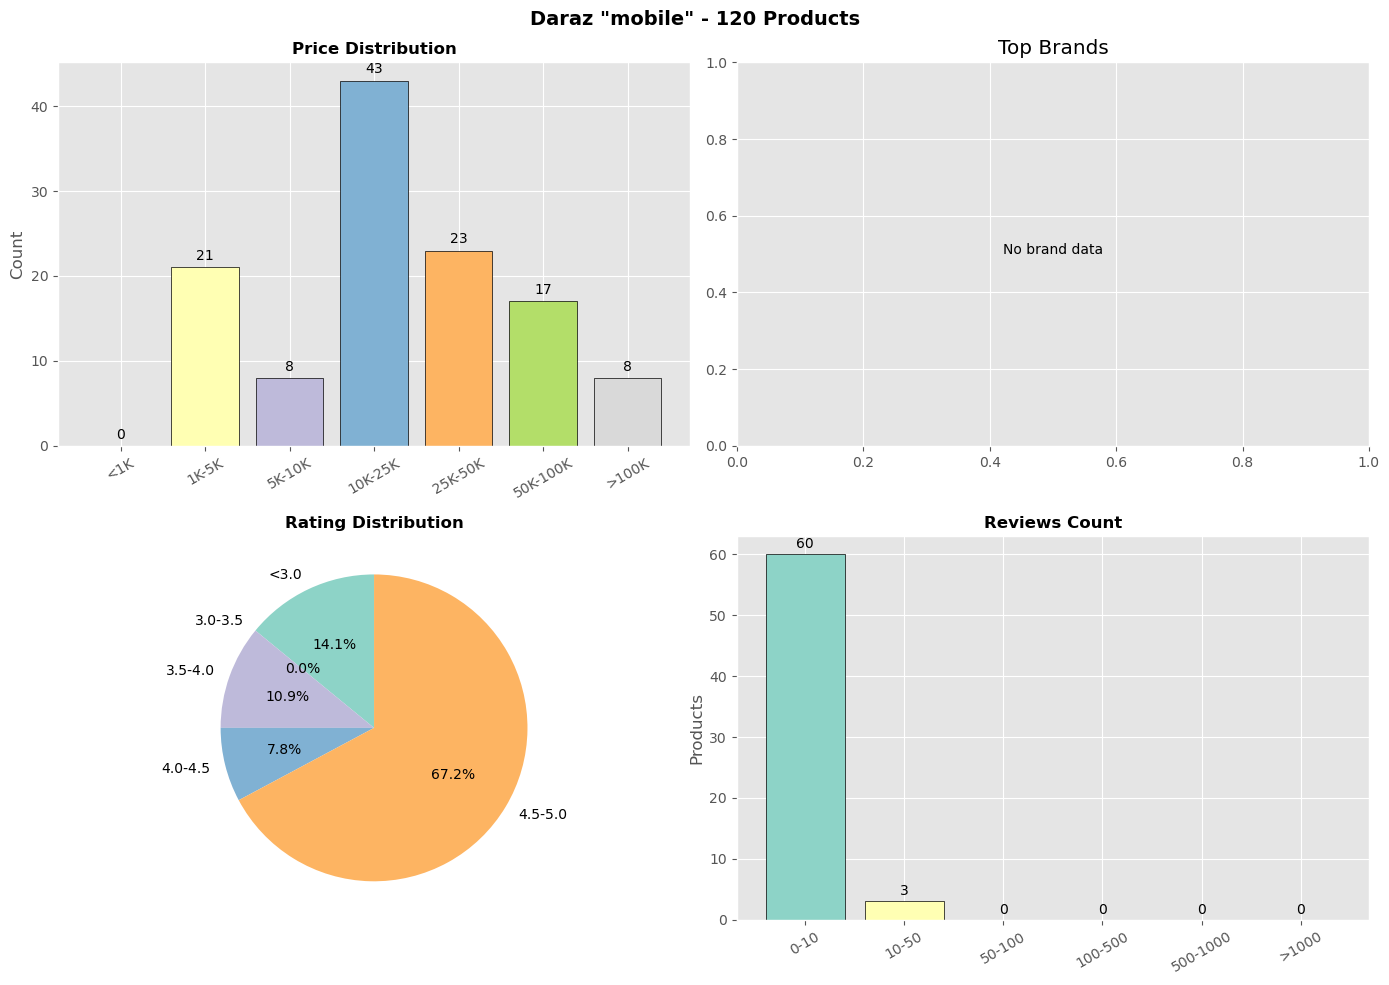

In [8]:
plt.style.use('ggplot')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Daraz "{keyword}" - {len(df)} Products', fontsize=14, weight='bold')

colors = plt.cm.Set3(np.linspace(0, 1, 10))

# (1) Price Distribution (Bar)
ax = axes[0,0]
bins = [0, 1000, 5000, 10000, 25000, 50000, 100000, float('inf')]
labels = ['<1K', '1K-5K', '5K-10K', '10K-25K', '25K-50K', '50K-100K', '>100K']
df['Price Range'] = pd.cut(df['Price (Rs.)'], bins=bins, labels=labels)
price_counts = df['Price Range'].value_counts().sort_index()
bars = ax.bar(price_counts.index, price_counts.values, color=colors[:len(price_counts)], edgecolor='black')
ax.set_title('Price Distribution', fontsize=12, weight='bold')
ax.set_ylabel('Count')
for bar, val in zip(bars, price_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', va='bottom')
ax.tick_params(axis='x', rotation=30)

# (2) Top Brands (Pie/Bar)
ax = axes[0,1]
brand_counts = df['Brand'].value_counts().head(8) if 'Brand' in df.columns else pd.Series()
if not brand_counts.empty:
    brand_counts.plot(kind='bar', ax=ax, color=colors[:len(brand_counts)], edgecolor='black')
    ax.set_title('Top Brands', fontsize=12, weight='bold')
    ax.set_ylabel('Count')
    for i, v in enumerate(brand_counts.values):
        ax.text(i, v+0.5, str(v), ha='center', va='bottom')
else:
    ax.text(0.5, 0.5, 'No brand data', ha='center', transform=ax.transAxes)
    ax.set_title('Top Brands')

# (3) Rating Distribution (Pie)
ax = axes[1,0]
if df['Rating'].notna().any():
    bins = [0, 3, 3.5, 4, 4.5, 5]
    labels = ['<3.0', '3.0-3.5', '3.5-4.0', '4.0-4.5', '4.5-5.0']
    df['Rating Range'] = pd.cut(df['Rating'].dropna(), bins=bins, labels=labels)
    rating_counts = df['Rating Range'].value_counts().sort_index()
    if not rating_counts.empty:
        wedges, texts, autotexts = ax.pie(rating_counts.values, labels=rating_counts.index,
                                          autopct='%1.1f%%', colors=colors[:len(rating_counts)],
                                          startangle=90)
        ax.set_title('Rating Distribution', fontsize=12, weight='bold')
    else:
        ax.text(0.5, 0.5, 'No ratings', ha='center', transform=ax.transAxes)
        ax.set_title('Rating Distribution')
else:
    ax.text(0.5, 0.5, 'No ratings', ha='center', transform=ax.transAxes)
    ax.set_title('Rating Distribution')

# (4) Reviews Distribution (Bar)
ax = axes[1,1]
if df['Reviews'].sum() > 0:
    bins = [0, 10, 50, 100, 500, 1000, float('inf')]
    labels = ['0-10', '10-50', '50-100', '100-500', '500-1000', '>1000']
    df['Reviews Range'] = pd.cut(df['Reviews'], bins=bins, labels=labels)
    rev_counts = df['Reviews Range'].value_counts().sort_index()
    bars = ax.bar(rev_counts.index, rev_counts.values, color=colors[:len(rev_counts)], edgecolor='black')
    ax.set_title('Reviews Count', fontsize=12, weight='bold')
    ax.set_ylabel('Products')
    for bar, val in zip(bars, rev_counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, str(val), ha='center', va='bottom')
    ax.tick_params(axis='x', rotation=30)
else:
    ax.text(0.5, 0.5, 'No reviews', ha='center', transform=ax.transAxes)
    ax.set_title('Reviews Count')

plt.tight_layout()
plt.show()